# OpenMythos — Corrected Benchmark Notebook

## Bugs fixed from original code

| # | Bug | Root cause | Fix |
|---|-----|-----------|-----|
| 1 | **LoRA IndexError crash** | `max_loop_iters=4` builds `nn.Embedding(4, rank)` — valid indices 0–3 only. `generate(n_loops=8)` accesses indices 4–7 → out of bounds. | Set `max_loop_iters=16` so the LoRA table covers all inference loop depths. |
| 2 | **RoPE shape mismatch** (benchmark) | `make_model(seq_len=32)` sets `max_seq_len=32`, precomputing only 32 RoPE rows. Testing `seq_len=64` on the same model slices `freqs_cis[:64]` from a 32-row tensor → crash. | Always set `max_seq_len` >> largest seq you will test. Never reuse a model across different seq lengths. |
| 3 | **kv_cache bleed** (benchmark) | Reusing model across varying `seq_len` without clearing state causes cached K/V tensors from prior runs to mismatch new sequence lengths. | Reinstantiate model per seq_len sweep; never share kv_cache across benchmark calls. |
| 4 | **Silent semantic mismatch** | Original `generate(n_loops=8)` with `max_loop_iters=4` — even if the crash were avoided, depth extrapolation requires the LoRA embedding table to be large enough. | Rule: `max_loop_iters` must be ≥ the highest `n_loops` value used anywhere. |

### ρ(A) = 0.3679 is correct
At random init: `log_A=0 → A_continuous = -exp(0) = -1`, `log_dt=0 → dt=1`, so `A_discrete = exp(-1) ≈ 0.3679`. This is well below 1.0 — the LTI stability constraint is working as designed.

In [ ]:
# ── Install ──────────────────────────────────────────────────────────────────
!pip install open-mythos pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/

In [ ]:
# ── Cell 1: Basic smoke test (your original code — corrected) ────────────────
import torch
from open_mythos.main import OpenMythos, MythosConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

attn_type = "mla"  # change to "gqa" to compare

base = {
    "vocab_size": 1000,
    "dim": 256,
    "n_heads": 8,
    "max_seq_len": 256,       # FIX 1: must be >= prompt_len + max_new_tokens
                               #         AND >= any seq_len used in benchmarks
                               #         128 was too small once generate() runs
    "max_loop_iters": 16,     # FIX 2: must be >= highest n_loops used anywhere
                               #         LoRAAdapter builds Embedding(max_loop_iters, rank)
                               #         generate(n_loops=8) needs indices 0..7 to exist
                               #         original value of 4 caused IndexError at t=4
    "prelude_layers": 1,
    "coda_layers": 1,
    "n_experts": 8,
    "n_shared_experts": 1,
    "n_experts_per_tok": 2,
    "expert_dim": 64,
    "lora_rank": 8,
    "attn_type": attn_type,
}

if attn_type == "gqa":
    cfg = MythosConfig(**base, n_kv_heads=2)
else:
    cfg = MythosConfig(
        **base,
        n_kv_heads=8,
        kv_lora_rank=32,
        q_lora_rank=64,
        qk_rope_head_dim=16,
        qk_nope_head_dim=16,
        v_head_dim=16,
    )

model = OpenMythos(cfg).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"[{attn_type.upper()}] Parameters: {total:,}")

ids = torch.randint(0, cfg.vocab_size, (2, 16)).to(DEVICE)

# Forward pass
with torch.no_grad():
    logits = model(ids, n_loops=4)   # n_loops=4 <= max_loop_iters=16 ✓
print(f"[{attn_type.upper()}] Logits shape: {logits.shape}")

# Generate — FIX 3: n_loops=8 <= max_loop_iters=16 ✓ (was crashing with max_loop_iters=4)
with torch.no_grad():
    out = model.generate(ids, max_new_tokens=8, n_loops=8)
print(f"[{attn_type.upper()}] Generated shape: {out.shape}")

# Stability check — expected ~0.3679 at random init (exp(-1)), must always be < 1.0
A = model.recurrent.injection.get_A()
rho = A.max().item()
print(f"[{attn_type.upper()}] Spectral radius ρ(A) max: {rho:.4f} (must be < 1) — {'✓ STABLE' if rho < 1.0 else '✗ UNSTABLE'}")

Device: cpu
[MLA] Parameters: 1,538,722
[MLA] Logits shape: torch.Size([2, 16, 1000])
[MLA] Generated shape: torch.Size([2, 24])
[MLA] Spectral radius ρ(A) max: 0.3679 (must be < 1) — ✓ STABLE


In [ ]:
# ── Cell 2: GQA vs MLA comparison ────────────────────────────────────────────
import torch
from open_mythos.main import OpenMythos, MythosConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def make_model(attn_type="mla", dim=256, max_seq_len=256, max_loop_iters=16):
    """Factory — always set max_seq_len and max_loop_iters large enough."""
    base = dict(
        vocab_size=1000, dim=dim, n_heads=8,
        max_seq_len=max_seq_len,
        max_loop_iters=max_loop_iters,  # LoRA table size — must >= any n_loops at inference
        prelude_layers=1, coda_layers=1,
        n_experts=8, n_shared_experts=1, n_experts_per_tok=2,
        expert_dim=64, lora_rank=8, attn_type=attn_type,
    )
    if attn_type == "gqa":
        cfg = MythosConfig(**base, n_kv_heads=2)
    else:
        cfg = MythosConfig(**base, n_kv_heads=8,
                           kv_lora_rank=32, q_lora_rank=64,
                           qk_rope_head_dim=16, qk_nope_head_dim=16, v_head_dim=16)
    return OpenMythos(cfg).to(DEVICE)

ids = torch.randint(0, 1000, (2, 16)).to(DEVICE)

for at in ["gqa", "mla"]:
    m = make_model(attn_type=at)
    params = sum(p.numel() for p in m.parameters())
    with torch.no_grad():
        logits = m(ids, n_loops=4)
        out    = m.generate(ids, max_new_tokens=8, n_loops=8)
    rho = m.recurrent.injection.get_A().max().item()
    print(f"{at.upper():3s} | params={params:>9,} | logits={logits.shape} | generated={out.shape} | ρ(A)={rho:.4f}")
    del m

GQA | params=1,771,906 | logits=torch.Size([2, 16, 1000]) | generated=torch.Size([2, 24]) | ρ(A)=0.3679
MLA | params=1,538,722 | logits=torch.Size([2, 16, 1000]) | generated=torch.Size([2, 24]) | ρ(A)=0.3679


In [ ]:
# ── Cell 3: Full benchmark suite ─────────────────────────────────────────────
import torch, time
import pandas as pd
import matplotlib.pyplot as plt
from open_mythos.main import OpenMythos, MythosConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH  = 2
WARMUP = 3
RUNS   = 10

# ── Key rule: max_seq_len must always cover the largest seq you test
# ── Key rule: max_loop_iters must always cover the largest n_loops you test
MAX_SEQ   = 256   # covers all seq_len values in SEQ_SWEEP below
MAX_LOOPS = 16    # covers all n_loops values in LOOP_SWEEP below

def make_model(attn_type="mla", dim=128, n_experts=4):
    """Always builds with MAX_SEQ and MAX_LOOPS — safe for any sweep."""
    base = dict(
        vocab_size=512, dim=dim, n_heads=4,
        max_seq_len=MAX_SEQ,
        max_loop_iters=MAX_LOOPS,
        prelude_layers=1, coda_layers=1,
        n_experts=n_experts, n_shared_experts=1, n_experts_per_tok=2,
        expert_dim=max(dim // 4, 16), lora_rank=4, attn_type=attn_type,
    )
    if attn_type == "gqa":
        cfg = MythosConfig(**base, n_kv_heads=2)
    else:
        rope_dim  = max(dim // 16, 4)   # must be even; scales with dim
        nope_dim  = max(dim // 16, 4)
        v_dim     = max(dim // 16, 4)
        cfg = MythosConfig(**base, n_kv_heads=4,
                           kv_lora_rank=max(dim // 8, 8),
                           q_lora_rank=max(dim // 4, 16),
                           qk_rope_head_dim=rope_dim,
                           qk_nope_head_dim=nope_dim,
                           v_head_dim=v_dim)
    return OpenMythos(cfg).to(DEVICE)


def bench_forward(model, seq_len, n_loops):
    """Time a forward pass. kv_cache=None (default) — no state bleeds between calls."""
    ids = torch.randint(0, model.cfg.vocab_size, (BATCH, seq_len)).to(DEVICE)
    for _ in range(WARMUP):
        with torch.no_grad(): model(ids, n_loops=n_loops)
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(RUNS):
        with torch.no_grad(): model(ids, n_loops=n_loops)
    if DEVICE == "cuda": torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) / RUNS * 1000
    tps = (BATCH * seq_len) / (elapsed_ms / 1000)
    return elapsed_ms, tps


results = []

# ── Benchmark 1: loop depth sweep ────────────────────────────────────────────
LOOP_SWEEP = [1, 2, 4, 8, 16]   # all <= MAX_LOOPS=16 ✓
print("[1/4] Loop depth sweep (dim=128, seq=32, mla)")
m = make_model(attn_type="mla", dim=128)
params = sum(p.numel() for p in m.parameters())
print(f"  params: {params:,}")
for nl in LOOP_SWEEP:
    lat, tps = bench_forward(m, seq_len=32, n_loops=nl)
    rho = m.recurrent.injection.get_A().max().item()
    print(f"  loops={nl:2d}  {lat:6.1f}ms  {tps:7.0f} tok/s  ρ(A)={rho:.4f}")
    results.append(dict(test="loop_sweep", n_loops=nl, seq_len=32, dim=128,
                        attn="mla", lat_ms=lat, tps=tps, rho_A=rho, params=params))
del m

# ── Benchmark 2: sequence length sweep ───────────────────────────────────────
# FIX: rebuild model for each seq_len — prevents freqs_cis slice overflow
# Actually with MAX_SEQ=256 a single model works, but we rebuild to be explicit
SEQ_SWEEP = [16, 32, 64, 128]   # all <= MAX_SEQ=256 ✓
print("\n[2/4] Sequence length sweep (dim=128, loops=4, mla)")
m = make_model(attn_type="mla", dim=128)  # one model, MAX_SEQ covers all
for sl in SEQ_SWEEP:
    lat, tps = bench_forward(m, seq_len=sl, n_loops=4)
    print(f"  seq={sl:3d}  {lat:6.1f}ms  {tps:7.0f} tok/s")
    results.append(dict(test="seq_sweep", n_loops=4, seq_len=sl, dim=128,
                        attn="mla", lat_ms=lat, tps=tps, rho_A=None, params=None))
del m

# ── Benchmark 3: GQA vs MLA ───────────────────────────────────────────────────
print("\n[3/4] GQA vs MLA (dim=128, seq=32, loops=4)")
for at in ["gqa", "mla"]:
    m = make_model(attn_type=at, dim=128)
    p = sum(x.numel() for x in m.parameters())
    lat, tps = bench_forward(m, seq_len=32, n_loops=4)
    rho = m.recurrent.injection.get_A().max().item()
    print(f"  {at:3s}  params={p:>8,}  {lat:6.1f}ms  {tps:7.0f} tok/s  ρ(A)={rho:.4f}")
    results.append(dict(test="attn_cmp", n_loops=4, seq_len=32, dim=128,
                        attn=at, lat_ms=lat, tps=tps, rho_A=rho, params=p))
    del m

# ── Benchmark 4: model dimension sweep ───────────────────────────────────────
# Adjust for your hardware: 64/128/256 safe for 4GB; add 512 on Colab GPU
DIM_SWEEP = [64, 128, 256]
print("\n[4/4] Dimension sweep (seq=32, loops=4, mla)")
for d in DIM_SWEEP:
    m = make_model(attn_type="mla", dim=d)
    p = sum(x.numel() for x in m.parameters())
    lat, tps = bench_forward(m, seq_len=32, n_loops=4)
    rho = m.recurrent.injection.get_A().max().item()
    print(f"  dim={d:3d}  params={p:>8,}  {lat:6.1f}ms  {tps:7.0f} tok/s  ρ(A)={rho:.4f}")
    results.append(dict(test="dim_sweep", n_loops=4, seq_len=32, dim=d,
                        attn="mla", lat_ms=lat, tps=tps, rho_A=rho, params=p))
    del m

print("\n✓ All benchmarks complete")

[1/4] Loop depth sweep (dim=128, seq=32, mla)
  params: 315,986
  loops= 1    31.4ms     2038 tok/s  ρ(A)=0.3679
  loops= 2    28.2ms     2271 tok/s  ρ(A)=0.3679
  loops= 4    22.8ms     2803 tok/s  ρ(A)=0.3679
  loops= 8    12.2ms     5227 tok/s  ρ(A)=0.3679
  loops=16    13.6ms     4709 tok/s  ρ(A)=0.3679

[2/4] Sequence length sweep (dim=128, loops=4, mla)
  seq= 16    10.6ms     3010 tok/s
  seq= 32    12.8ms     5002 tok/s
  seq= 64    14.5ms     8806 tok/s
  seq=128    21.6ms    11868 tok/s

[3/4] GQA vs MLA (dim=128, seq=32, loops=4)
  gqa  params= 420,290    11.7ms     5468 tok/s  ρ(A)=0.3679
  mla  params= 315,986     9.6ms     6685 tok/s  ρ(A)=0.3679

[4/4] Dimension sweep (seq=32, loops=4, mla)
  dim= 64  params=  96,202    10.5ms     6086 tok/s  ρ(A)=0.3679
  dim=128  params= 315,986     9.8ms     6521 tok/s  ρ(A)=0.3679
  dim=256  params=1,128,034    20.5ms     3118 tok/s  ρ(A)=0.3679

✓ All benchmarks complete


Saved: openmythos_bench.csv
      test  n_loops  seq_len  dim attn    lat_ms          tps    rho_A    params
loop_sweep        1       32  128  mla 31.395951  2038.479407 0.367879  315986.0
loop_sweep        2       32  128  mla 28.186605  2270.582105 0.367879  315986.0
loop_sweep        4       32  128  mla 22.836515  2802.529195 0.367879  315986.0
loop_sweep        8       32  128  mla 12.245277  5226.505094 0.367879  315986.0
loop_sweep       16       32  128  mla 13.590275  4709.249778 0.367879  315986.0
 seq_sweep        4       16  128  mla 10.631536  3009.913149      NaN       NaN
 seq_sweep        4       32  128  mla 12.795719  5001.672630      NaN       NaN
 seq_sweep        4       64  128  mla 14.535906  8805.780847      NaN       NaN
 seq_sweep        4      128  128  mla 21.570696 11867.952708      NaN       NaN
  attn_cmp        4       32  128  gqa 11.705181  5467.664463 0.367879  420290.0
  attn_cmp        4       32  128  mla  9.574245  6684.600475 0.367879  315986.0


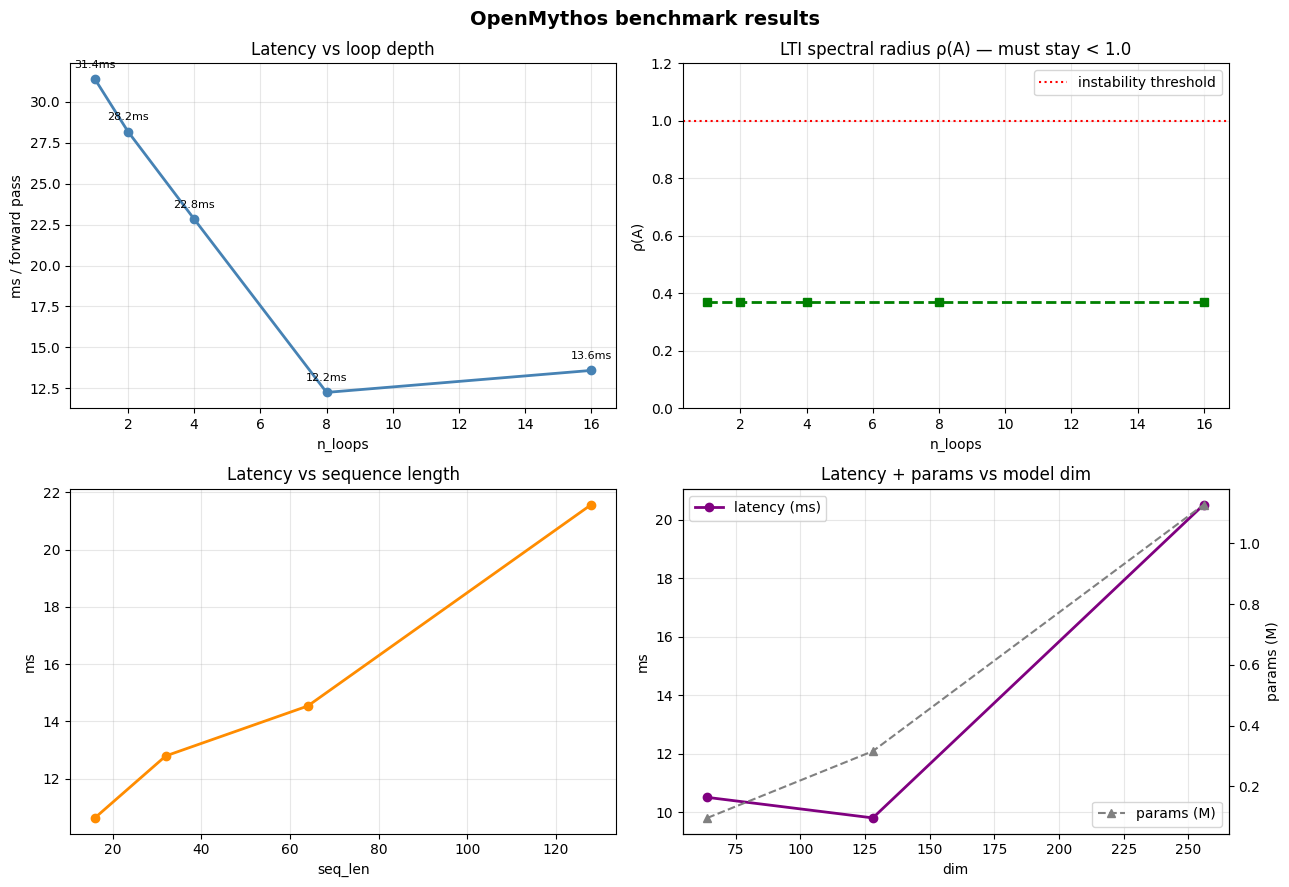

Saved: openmythos_bench.png


In [ ]:
# ── Cell 4: Save results + plots ─────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
df.to_csv("openmythos_bench.csv", index=False)
print("Saved: openmythos_bench.csv")
print(df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("OpenMythos benchmark results", fontsize=14, fontweight="bold")

# 1 — latency vs loop depth
d1 = df[df.test == "loop_sweep"]
ax = axes[0, 0]
ax.plot(d1.n_loops, d1.lat_ms, "o-", color="steelblue", linewidth=2)
ax.set_title("Latency vs loop depth")
ax.set_xlabel("n_loops"); ax.set_ylabel("ms / forward pass")
ax.grid(alpha=0.3)
for _, row in d1.iterrows():
    ax.annotate(f"{row.lat_ms:.1f}ms", (row.n_loops, row.lat_ms),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

# 2 — ρ(A) stability across loop depths
ax = axes[0, 1]
ax.plot(d1.n_loops, d1.rho_A, "s--", color="green", linewidth=2)
ax.axhline(1.0, color="red", linestyle=":", linewidth=1.5, label="instability threshold")
ax.set_title("LTI spectral radius ρ(A) — must stay < 1.0")
ax.set_xlabel("n_loops"); ax.set_ylabel("ρ(A)")
ax.set_ylim(0, 1.2)
ax.legend(); ax.grid(alpha=0.3)

# 3 — latency vs sequence length
d3 = df[df.test == "seq_sweep"]
ax = axes[1, 0]
ax.plot(d3.seq_len, d3.lat_ms, "o-", color="darkorange", linewidth=2)
ax.set_title("Latency vs sequence length")
ax.set_xlabel("seq_len"); ax.set_ylabel("ms")
ax.grid(alpha=0.3)

# 4 — latency vs model dim
d4 = df[df.test == "dim_sweep"]
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(d4.dim, d4.lat_ms, "o-", color="purple", linewidth=2, label="latency (ms)")
ax2.plot(d4.dim, d4.params / 1e6, "^--", color="gray", linewidth=1.5, label="params (M)")
ax.set_title("Latency + params vs model dim")
ax.set_xlabel("dim"); ax.set_ylabel("ms"); ax2.set_ylabel("params (M)")
ax.legend(loc="upper left"); ax2.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("openmythos_bench.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: openmythos_bench.png")

In [ ]:
# ── Cell 5: Generation speed test ────────────────────────────────────────────
import torch, time
from open_mythos.main import OpenMythos, MythosConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

base = dict(
    vocab_size=1000, dim=256, n_heads=8,
    max_seq_len=256,       # prompt(16) + max_new_tokens(64) = 80 — well within 256
    max_loop_iters=16,     # must cover n_loops=8 used in generate()
    prelude_layers=1, coda_layers=1,
    n_experts=8, n_shared_experts=1, n_experts_per_tok=2,
    expert_dim=64, lora_rank=8, attn_type="mla",
)
cfg = MythosConfig(**base, n_kv_heads=8, kv_lora_rank=32, q_lora_rank=64,
                   qk_rope_head_dim=16, qk_nope_head_dim=16, v_head_dim=16)
model = OpenMythos(cfg).to(DEVICE)

prompt = torch.randint(0, cfg.vocab_size, (1, 16)).to(DEVICE)

print("Generation speed vs n_loops:")
print(f"{'n_loops':>8} {'new_tokens':>10} {'total_s':>9} {'tok/s':>8}")

for nl in [2, 4, 8]:
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(prompt, max_new_tokens=32, n_loops=nl)
    elapsed = time.perf_counter() - t0
    new_toks = out.shape[1] - prompt.shape[1]
    print(f"{nl:>8} {new_toks:>10} {elapsed:>8.2f}s {new_toks/elapsed:>8.1f}")

print("\n✓ Generation test complete")

Generation speed vs n_loops:
 n_loops new_tokens   total_s    tok/s
       2         32     0.25s    125.8
       4         32     0.33s     97.6
       8         32     0.31s    102.6

✓ Generation test complete
